# SimCLR Contrastive Training for UCI-HAR Dataset


In [1]:
# Author: C. I. Tang
# Adapted for UCI-HAR by Mochi
# Based on work of Tang et al.: https://arxiv.org/abs/2011.11542
# License: GNU General Public License v3.0

%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

I0000 00:00:1774935985.406172  619276 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774935985.407556  619276 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774935985.921328  619276 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1774935988.149266  619276 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774935988.150540  619276 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# Libraries for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.manifold

sns.set_context('poster')

In [4]:
# Library scripts
import raw_data_processing
import data_pre_processing
import simclr_models
import simclr_utitlities
import transformations

In [5]:
working_directory = 'test_run/'
dataset_save_path = working_directory
if not os.path.exists(working_directory):
    os.mkdir(working_directory)

## UCI-HAR Dataset

UCI Human Activity Recognition Using Smartphones Dataset


In [6]:
# Load UCI-HAR
data_folder_path = 'datasets/UCI-HAR/UCI HAR Dataset/'
user_datasets = raw_data_processing.process_uci_har(data_folder_path)

Loaded UCI-HAR dataset: 30 users
Total windows: 10299


## Pre-processing

In [7]:
# Parameters
# UCI-HAR: 50Hz sampling rate, each window is already 128 timesteps
window_size = 128
input_shape = (window_size, 3)

# Dataset Metadata 
transformation_multiple = 1
dataset_name = 'ucihar.pkl'
dataset_name_user_split = 'ucihar_user_split.pkl'

# UCI-HAR labels
label_list = [
    'null', 
    'WALKING', 
    'WALKING_UPSTAIRS', 
    'WALKING_DOWNSTAIRS', 
    'SITTING', 
    'STANDING', 
    'LAYING'
]
label_map = dict([(l, i) for i, l in enumerate(label_list)])
output_shape = len(label_list)

model_save_name = f"ucihar_acc"

# Original UCI-HAR already has train/test split, we'll keep that
def get_fixed_split_users(har_users):
    # UCI-HAR original split: train = subjects 1-30 except test, test =  2, 4, 9, 10, 12, 13, 18, 20, 24
    test_users = [2, 4, 9, 10, 12, 13, 18, 20, 24]
    train_users = [u for u in har_users if u not in test_users]
    return (train_users, test_users)

In [8]:
with open(dataset_save_path + dataset_name_user_split, 'wb') as f:
    pickle.dump({
        'user_split': user_datasets,
    }, f)

In [9]:
har_users = list(user_datasets.keys())
train_users, test_users = get_fixed_split_users(har_users)
print(f'Testing: {test_users}, Training: {train_users}')

Testing: [2, 4, 9, 10, 12, 13, 18, 20, 24], Training: [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]


In [10]:
np_train, np_val, np_test = data_pre_processing.pre_process_dataset_composite(
    user_datasets=user_datasets, 
    label_map=label_map, 
    output_shape=output_shape, 
    train_users=train_users, 
    test_users=test_users, 
    window_size=window_size, 
    shift=window_size//2, 
    normalise_dataset=True, 
    verbose=1
)


Test
(array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype='<U18'), array([537, 491, 532, 496, 420, 471]))
(array([1, 2, 3, 4, 5, 6]), array([496, 471, 420, 491, 532, 537]))
-----------------
Train
(array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype='<U18'), array([1407, 1286, 1374, 1226,  986, 1073]))
(array([1, 2, 3, 4, 5, 6]), array([1226, 1073,  986, 1286, 1374, 1407]))
-----------------
Training data shape: (5881, 128, 3)
Validation data shape: (1471, 128, 3)
Testing data shape: (2947, 128, 3)


## SimCLR Training

In [11]:
batch_size = 512
decay_steps = 1000
epochs = 200
temperature = 0.1
transform_funcs = [
    # transformations.scaling_transform_vectorized, # Use Scaling transformation
    transformations.rotation_transform_vectorized # Use rotation transformation
]
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function rotation_transform_vectorized at 0x7f88d966e020>


In [12]:
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
tf.keras.backend.set_floatx('float32')

lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_decayed_fn)

base_model = simclr_models.create_base_model(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(simclr_model, np_train[0], optimizer, batch_size, transformation_function, temperature=temperature, epochs=epochs, is_trasnform_function_vectorized=True, verbose=1)

simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.keras"
trained_simclr_model.save(simclr_model_save_path)

E0000 00:00:1774935992.570884  619276 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 105, 32)        │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 105, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 90, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 83, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 83, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

...

epoch: 196 loss: 0.516


epoch: 197 loss: 0.518


epoch: 198 loss: 0.524


epoch: 199 loss: 0.521


epoch: 200 loss: 0.520


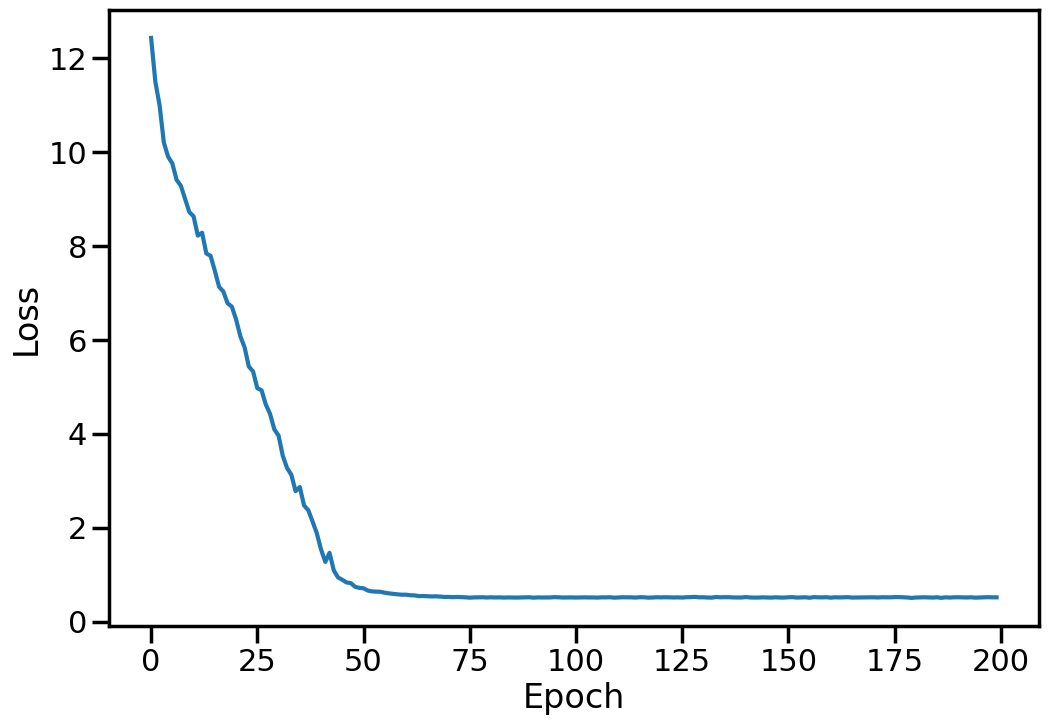

In [13]:
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## Fine-tuning and Evaluation

### Linear Model

In [14]:
total_epochs = 50
batch_size = 200

tag = "linear_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(linear_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = linear_evaluation_model.fit(
    x = np_train[0],
    y = np_train[1],
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=np_val
)

linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(np_test[0]), np_test[1], return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(np_test[0]), np_test[1], return_dict=True))

Epoch 1/50


 1/30 ━━━━━━━━━━━━━━━━━━━━ 15s 536ms/step - auc: 0.5125 - categorical_accuracy: 0.0950 - loss: 3.4428 - precision: 0.2143 - recall: 0.0900

 3/30 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - auc: 0.5176 - categorical_accuracy: 0.1247 - loss: 22.2264 - precision: 0.1966 - recall: 0.1217 

 5/30 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - auc: 0.5418 - categorical_accuracy: 0.1511 - loss: 27.3367 - precision: 0.2070 - recall: 0.1439

 7/30 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - auc: 0.5606 - categorical_accuracy: 0.1748 - loss: 28.6426 - precision: 0.2243 - recall: 0.1657

...

76/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


{'Confusion Matrix': array([[417,  43,  31,   0,   0,   5],
       [  7, 433,  13,   0,   0,  18],
       [ 24,  15, 372,   0,   0,   9],
       [  5,   2,   0,   0,   0, 484],
       [  7,   3,   1,   0,   0, 521],
       [  5,   0,   0,   0,   1, 531]]), 'F1 Macro': 0.5261335340459706, 'F1 Micro': 0.5948422124194096, 'F1 Weighted': 0.5078093131853652, 'Precision': 0.5000820591058422, 'Recall': 0.6057645837146978, 'Kappa': 0.5114835555018733}


/home/fandy/workplace/thesis/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Full HAR Model

In [15]:
total_epochs = 50
batch_size = 200
tag = "full_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train[0],
    y = np_train[1],
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=np_val
)

full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(np_test[0]), np_test[1], return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(np_test[0]), np_test[1], return_dict=True))

Epoch 1/50


 1/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - auc: 0.5466 - categorical_accuracy: 0.2650 - loss: 6.7895 - precision: 0.3667 - recall: 0.1650

 3/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - auc: 0.5709 - categorical_accuracy: 0.2336 - loss: 6.4656 - precision: 0.3357 - recall: 0.1644

 5/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - auc: 0.5844 - categorical_accuracy: 0.2337 - loss: 6.0113 - precision: 0.3268 - recall: 0.1637

 7/30 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - auc: 0.6064 - categorical_accuracy: 0.2491 - loss: 5.5448 - precision: 0.3422 - recall: 0.1733

...

62/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

78/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


{'Confusion Matrix': array([[468,  26,   2,   0,   0,   0],
       [  9, 460,   2,   0,   0,   0],
       [  2,   9, 409,   0,   0,   0],
       [  0,   0,   0, 211, 195,  85],
       [  0,   1,   0, 100, 367,  64],
       [  0,   0,   0,  75,  63, 399]]), 'F1 Macro': 0.7907429846421961, 'F1 Micro': 0.7852052935188327, 'F1 Weighted': 0.7822945546214445, 'Precision': 0.7927839882588796, 'Recall': 0.7927674940338387, 'Kappa': 0.7417648795717848}


## Extra: t-SNE Plots

### Parameters

In [16]:
# Select a model from which the intermediate representations are extracted
target_model = simclr_model 
perplexity = 30.0

### t-SNE Representations

In [17]:
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(target_model, intermediate_layer=7)
intermediate_model.summary()

embeddings = intermediate_model.predict(np_test[0], batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 105, 32)        │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 105, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 90, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 83, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 83, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 49,248 (192.38 KB)

 Non-trainable params: 35,168 (137.38 KB)

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2947 samples in 0.001s...
[t-SNE] Computed neighbors for 2947 samples in 0.105s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2947
[t-SNE] Computed conditional probabilities for sample 2000 / 2947
[t-SNE] Computed conditional probabilities for sample 2947 / 2947
[t-SNE] Mean sigma: 1.103965


[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.091087


[t-SNE] KL divergence after 1000 iterations: 1.168494


### Plotting

/tmp/ipykernel_619276/1458384847.py:4: UserWarning: Legend does not support handles for int instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(range(len(label_list)), label_list)


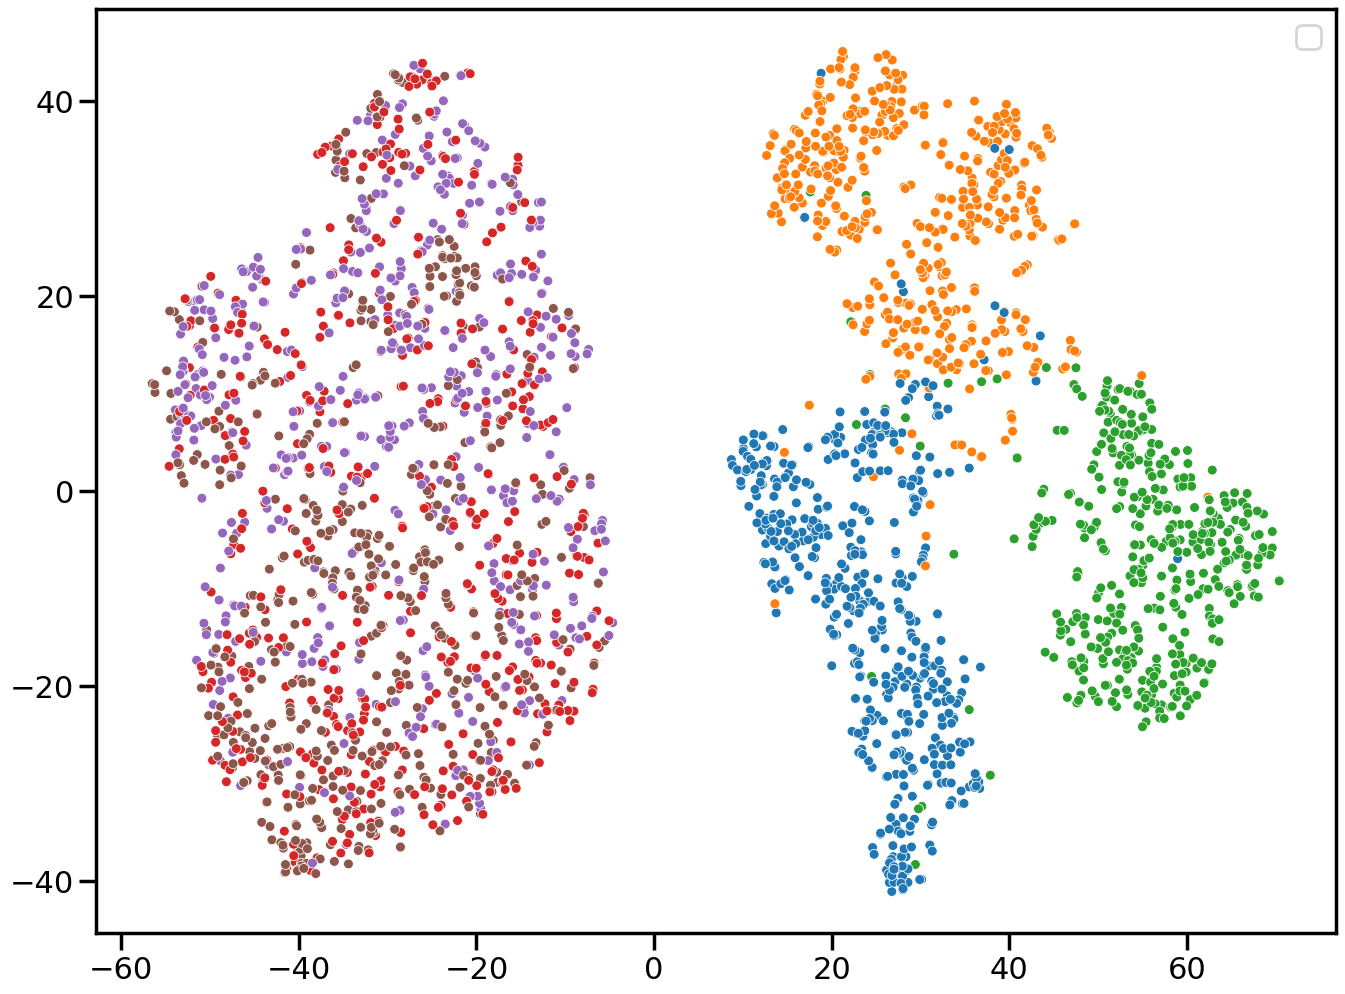

In [18]:
categories = np.argmax(np_test[1], axis=1)
plt.figure(figsize=(16, 12))
sns.scatterplot(x=tsne_projections[:,0], y=tsne_projections[:,1], hue=categories, palette='tab10', s=50)
plt.legend(range(len(label_list)), label_list)
plt.show()